<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/06_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[⬅ Back to the workshop index](https://github.com/lorenzkap/ML2026#-the-notebooks) · **Notebook 06 of the course**


# 🩺 Notebook 06 — Evaluating models like a clinician

> A model that is *right 82% of the time* can still be **useless — or dangerous — at the bedside**.
> In this notebook we stop trusting a single accuracy number and start evaluating a model the way
> you would judge a new diagnostic test: sensitivity, specificity, how many false alarms it raises,
> and whether a predicted *"20% risk"* really means 20%.

**What you'll learn**
- Why **accuracy is misleading** when only ≈18% of patients die (class imbalance).
- How to read a **confusion matrix** in clinical language (a false negative = a *missed death*).
- **ROC / AUC** vs **Precision–Recall / Average Precision**, and when each is the honest choice.
- How to **tune the decision threshold** to hit a target sensitivity — and count the alarm burden.
- **Calibration**: making sure a predicted risk of 20% actually happens 20% of the time.
- Why evaluation must respect **patient grouping** (a nod to `GroupKFold`).

**⏱️ Time:** ≈55 min · **Prerequisites:** Notebook 05 (your first models)


## ⚙️ Run me first

Run the setup cell below. It installs anything missing, sets a clean plotting style, and defines the
data loaders. *(Same setup cell as every notebook — no need to re-read it.)*

In [1]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 👩‍🏫 INSTRUCTORS: put a direct-download link to the workshop data here (or set the
# WORKSHOP_DATA_URL environment variable) and participants never upload anything.
# It must be a folder-style base URL that serves the CSVs by name, e.g.
#     "https://your-institution.example/sepsis_workshop/"
# Leave it empty ("") to use the upload flow instead. The data is NOT in the public
# GitHub repo on purpose — it is derived from MIMIC-IV and covered by a PhysioNet DUA.
WORKSHOP_DATA_URL = os.environ.get("WORKSHOP_DATA_URL", "")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    paths = [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]
    cache = _drive_cache()
    if cache:
        paths.append(os.path.join(cache, name))
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def _try_download(name):
    """If the instructor configured WORKSHOP_DATA_URL, fetch the file from there."""
    if not WORKSHOP_DATA_URL:
        return None
    import urllib.request
    url = WORKSHOP_DATA_URL.rstrip("/") + "/" + name
    try:
        print(f"⬇  downloading {name} …")
        urllib.request.urlretrieve(url, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV. Searches local folders, (in Colab) your Google-Drive cache, and
    the instructor's download link. If none of those work it asks you to upload the file
    ONCE, then saves a copy to Drive so the other notebooks find it automatically."""
    p = _find(name)
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)
    if p:
        data = pd.read_csv(p)
        print(f"✓ loaded {name}")
        _cache_to_drive(name, data)
        return data
    try:
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Ask your instructor for the workshop CSVs, then either "
            f"upload it when prompted, or put it next to this notebook / in a data/ folder."
        )


### The patient-level table

Notebook 04 taught you to squeeze the 4-hourly time-series into **one row per ICU stay**. Here is that
exact builder again, followed by `load_patients()` (which loads the saved file, or rebuilds it on the fly).

In [2]:
def build_patient_table(ts):
    """Aggregate the 4-hourly time-series into ONE row per ICU stay.
       (This is exactly what Notebook 04 teaches you to build.)"""
    df = ts.copy()
    # clean temperature: prefer Celsius; repair obvious Fahrenheit-entry errors; drop impossible
    tf = df["Temp_F"].where((df["Temp_F"] >= 90) & (df["Temp_F"] <= 110))
    tc = df["Temp_C"].where((df["Temp_C"] >= 25) & (df["Temp_C"] <= 45))
    df["Temp_C_clean"] = tc.fillna((tf - 32) * 5/9)
    # impossible vitals -> NaN, then forward/back-fill WITHIN each stay
    for c, lo, hi in [("HR",20,300),("SysBP",40,300),("MeanBP",20,220),("RR",3,80),("SpO2",30,100)]:
        df[c] = df[c].where((df[c] >= lo) & (df[c] <= hi))
    g = df.groupby("icustayid", group_keys=False)
    vit = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean"]
    df[vit] = g[vit].apply(lambda x: x.ffill().bfill())
    # winsorise skewed labs so one stray value can't define a min/max
    for c in ["Arterial_lactate","Creatinine","BUN","WBC_count","Platelets_count","INR","Glucose"]:
        lo, hi = df[c].quantile(0.01), df[c].quantile(0.99)
        df[c] = df[c].clip(lo, hi)
    tv = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean","GCS","Creatinine","BUN",
          "Arterial_lactate","WBC_count","Platelets_count","Potassium","Sodium",
          "Albumin","INR","Arterial_pH","Shock_Index","SOFA","SIRS","PaO2_FiO2","Hb"]
    grp = df.groupby("icustayid")
    f = {}
    f["age"]=grp["age"].first(); f["gender"]=grp["gender"].first()
    f["elixhauser"]=grp["elixhauser"].first(); f["re_admission"]=grp["re_admission"].first().astype(int)
    f["weight_kg"]=grp["Weight_kg"].median(); f["n_blocs"]=grp.size(); f["los_hours"]=grp["bloc"].max()*4
    f["mechvent_ever"]=grp["mechvent"].max(); f["vaso_max"]=grp["max_dose_vaso"].max()
    f["fluid_balance_last"]=grp["cumulated_balance"].last(); f["urine_total"]=grp["output_step"].sum()
    for c in tv:
        f[f"{c}_mean"]=grp[c].mean(); f[f"{c}_min"]=grp[c].min()
        f[f"{c}_max"]=grp[c].max();  f[f"{c}_last"]=grp[c].last()
    for c in ["Creatinine","Arterial_lactate","SOFA","Shock_Index","GCS"]:
        f[f"{c}_delta"]=grp[c].last()-grp[c].first()
    X = pd.DataFrame(f); X["morta_90"]=grp["morta_90"].max(); X["died_in_hosp"]=grp["died_in_hosp"].max()
    return X.reset_index()

def load_patients():
    p = _find("sepsis_patients.csv")
    if p:
        print(f"✓ loaded {p}"); return pd.read_csv(p)
    print("sepsis_patients.csv not found — building it from the time-series file…")
    return build_patient_table(load_csv("sepsis_timeseries.csv"))

## 🔧 Refit one good model (from Notebook 05)

Evaluation only makes sense with a trained model in hand, so we quickly rebuild the **gradient-boosted
tree (XGBoost)** from Notebook 05 — same features, same split, same parameters. No new modelling ideas
here; if this looks familiar, that's the point. Everything after this cell is about **judging** it.

In [3]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

patients = load_patients()

# Features = everything except the ID and the two outcome columns.
drop_cols = ["icustayid", "morta_90", "died_in_hosp"]
X = patients.drop(columns=drop_cols)
y = patients["morta_90"].astype(int)

# The patient table already has ONE row per patient, so a stratified split is safe here.
# (On the raw time-series you would split by icustayid — see the GroupKFold note at the end.)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
model = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    scale_pos_weight=neg / pos, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

# Predicted probability of death for every held-out patient.
proba = model.predict_proba(X_test)[:, 1]

print(f"Train patients: {len(X_train)}   Test patients: {len(X_test)}")
print(f"90-day mortality rate  ->  train {y_train.mean():.1%}   test {y_test.mean():.1%}")
print(f"Predicted-risk range on test set: {proba.min():.2f} to {proba.max():.2f}")

✓ loaded data/sepsis_patients.csv


Train patients: 1272   Test patients: 424
90-day mortality rate  ->  train 18.2%   test 18.2%
Predicted-risk range on test set: 0.00 to 0.97


## 🎭 Why accuracy lies

Sepsis 90-day mortality here is about **18%**. So a lazy "model" that simply predicts **everyone
survives** is already right ≈82% of the time — while catching *zero* deaths. Accuracy rewards the
majority class, which in medicine is usually the class we care about **least**.

Let's put our real model's accuracy next to that do-nothing baseline.

,model,accuracy,balanced_accuracy,recall (sensitivity)
0,Predict everyone survives,81.8%,50.0%,0.0%
1,XGBoost @ threshold 0.5,81.8%,65.7%,40.3%


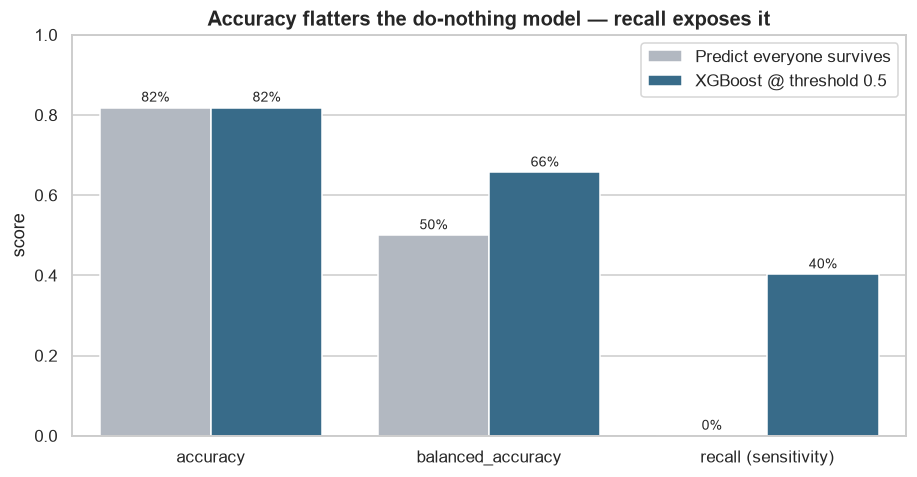

In [4]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score

pred_default = (proba >= 0.5).astype(int)          # our model at the usual 0.5 cut-off
pred_allsurv = np.zeros_like(y_test)               # "predict everyone survives"

rows = [
    ("Predict everyone survives", accuracy_score(y_test, pred_allsurv),
     balanced_accuracy_score(y_test, pred_allsurv), recall_score(y_test, pred_allsurv, zero_division=0)),
    ("XGBoost @ threshold 0.5", accuracy_score(y_test, pred_default),
     balanced_accuracy_score(y_test, pred_default), recall_score(y_test, pred_default)),
]
scoreboard = pd.DataFrame(rows, columns=["model", "accuracy", "balanced_accuracy", "recall (sensitivity)"])
display(scoreboard.style.format({"accuracy":"{:.1%}","balanced_accuracy":"{:.1%}","recall (sensitivity)":"{:.1%}"}))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
plot_df = scoreboard.melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="metric", y="score", hue="model", ax=ax, palette=["#b0b7c3", "#2a6f97"])
ax.set_title("Accuracy flatters the do-nothing model — recall exposes it", fontsize=13, weight="bold")
ax.set_ylabel("score"); ax.set_xlabel(""); ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f%%", labels=[f"{v*100:.0f}%" for v in c.datavalues], padding=2, fontsize=9)
ax.legend(title="", loc="upper right")
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** The "predict everyone survives" model has **high accuracy and zero
> sensitivity** — it never catches a death. That is exactly the trade-off a naïve accuracy number
> hides. Two honest habits: (1) always report **sensitivity/recall** for the outcome you care about,
> and (2) use **balanced accuracy** or the curves below when classes are imbalanced.

## 🔲 The confusion matrix — in clinical language

Every binary prediction lands in one of four boxes. Read them like a diagnostic-test 2×2:

| | Model says **survive** | Model says **die** |
|---|---|---|
| **Actually survived** | ✅ True Negative (TN) | ⚠️ False Positive (FP) — *false alarm* |
| **Actually died** | ❌ False Negative (FN) — **a missed death** | ✅ True Positive (TP) — *caught* |

- **FN (missed death)** is usually the costliest error in a screening/early-warning setting.
- **FP (false alarm)** costs clinician time and can cause alarm fatigue.

From these four numbers everything else is derived: **sensitivity = TP/(TP+FN)**,
**specificity = TN/(TN+FP)**, **PPV/precision = TP/(TP+FP)**.

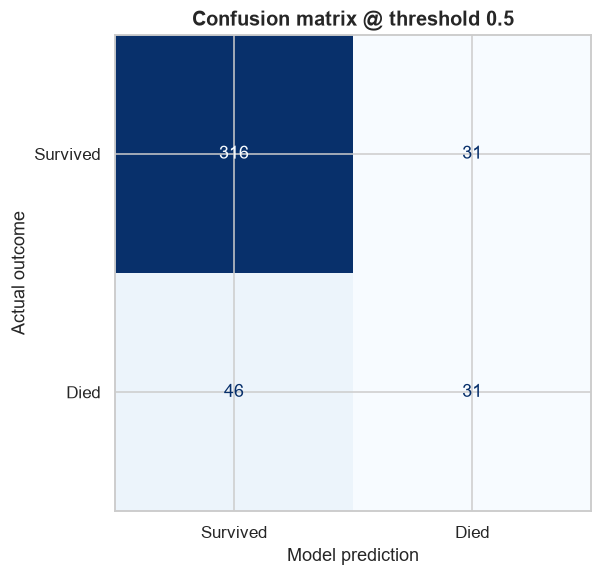

True Negatives  (correctly said survive): 316
False Positives (false alarms)          : 31
False Negatives (MISSED deaths)         : 46
True Positives  (caught deaths)         : 31

Sensitivity / recall : 40.3%   (of patients who died, how many we flagged)
Specificity          : 91.1%   (of survivors, how many we correctly cleared)
Precision / PPV      : 50.0%   (of our alarms, how many truly died)


In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, pred_default)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6.2, 5.4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survived", "Died"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion matrix @ threshold 0.5", fontsize=13, weight="bold")
ax.set_xlabel("Model prediction"); ax.set_ylabel("Actual outcome")
plt.tight_layout(); plt.show()

sens = tp / (tp + fn); spec = tn / (tn + fp); ppv = tp / (tp + fp)
print(f"True Negatives  (correctly said survive): {tn}")
print(f"False Positives (false alarms)          : {fp}")
print(f"False Negatives (MISSED deaths)         : {fn}")
print(f"True Positives  (caught deaths)         : {tp}")
print(f"\nSensitivity / recall : {sens:.1%}   (of patients who died, how many we flagged)")
print(f"Specificity          : {spec:.1%}   (of survivors, how many we correctly cleared)")
print(f"Precision / PPV      : {ppv:.1%}   (of our alarms, how many truly died)")

> 🧠 **Clinical takeaway.** Class-weighting (`scale_pos_weight`) pushed the model toward **high
> sensitivity** — it catches most deaths — at the cost of more false alarms (lower precision). Whether
> that trade is right depends on the clinical question. That is a **threshold decision**, and we get to
> choose it deliberately (later in this notebook), not accept 0.5 by default.

## 📈 ROC / AUC and Precision–Recall / AP

A single threshold gives one confusion matrix. But a model outputs a *probability*, so we can sweep
**every** threshold and trace a curve.

- **ROC curve** plots sensitivity vs (1 − specificity). The **AUC** is the probability the model ranks
  a random *decedent* above a random *survivor*. 0.5 = coin flip, 1.0 = perfect.
- **Precision–Recall curve** plots precision (PPV) vs recall (sensitivity). Its summary is **Average
  Precision (AP)**. Under heavy imbalance, PR is often the **more honest** picture because it ignores the
  huge, easy True-Negative pile that inflates ROC.

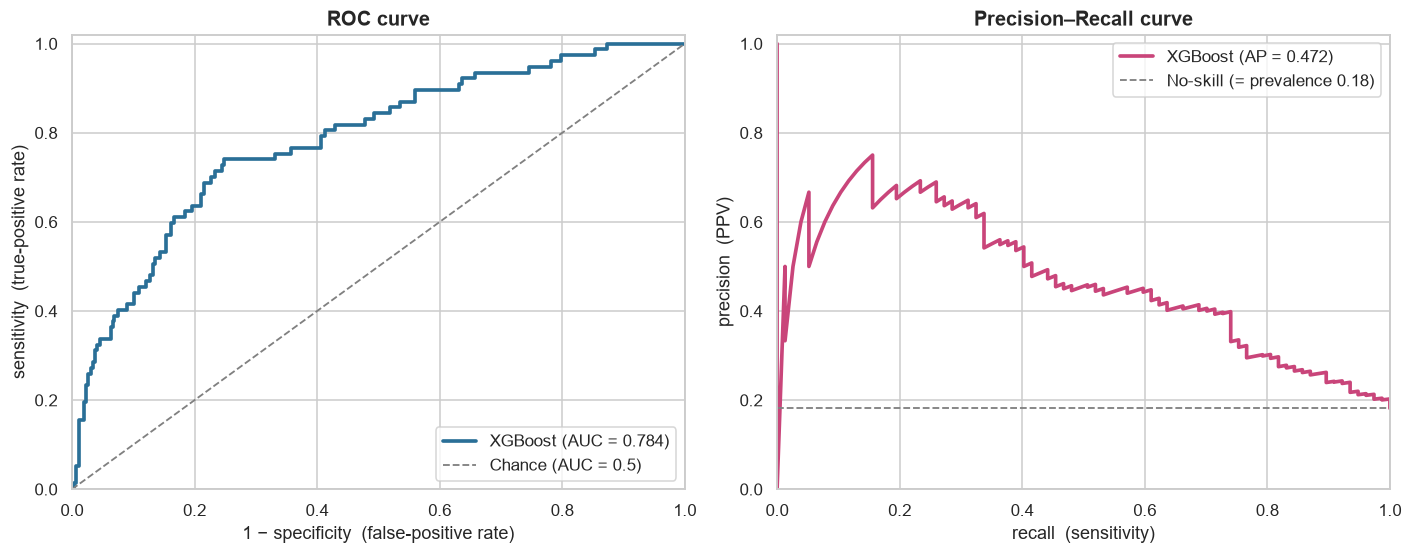

ROC-AUC = 0.784   |   Average Precision = 0.472   |   prevalence = 18.2%


In [6]:
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             roc_auc_score, average_precision_score)

auc = roc_auc_score(y_test, proba)
ap  = average_precision_score(y_test, proba)
prevalence = y_test.mean()

# Compute the curves by hand so the plot styling works on any sklearn version.
fpr, tpr, _ = roc_curve(y_test, proba)
prec_c, rec_c, _ = precision_recall_curve(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

axes[0].plot(fpr, tpr, color="#2a6f97", lw=2.4, label=f"XGBoost (AUC = {auc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="grey", lw=1.2, label="Chance (AUC = 0.5)")
axes[0].set_title("ROC curve", fontsize=13, weight="bold")
axes[0].set_xlabel("1 − specificity  (false-positive rate)")
axes[0].set_ylabel("sensitivity  (true-positive rate)")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02); axes[0].legend(loc="lower right")

axes[1].plot(rec_c, prec_c, color="#c9457a", lw=2.4, label=f"XGBoost (AP = {ap:.3f})")
axes[1].axhline(prevalence, ls="--", color="grey", lw=1.2,
                label=f"No-skill (= prevalence {prevalence:.2f})")
axes[1].set_title("Precision–Recall curve", fontsize=13, weight="bold")
axes[1].set_xlabel("recall  (sensitivity)"); axes[1].set_ylabel("precision  (PPV)")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02); axes[1].legend(loc="upper right")

plt.tight_layout(); plt.show()
print(f"ROC-AUC = {auc:.3f}   |   Average Precision = {ap:.3f}   |   prevalence = {prevalence:.1%}")

> 🧠 **Clinical takeaway.** The **no-skill lines differ**: ROC's baseline is the diagonal (0.5);
> PR's baseline is the **prevalence** (≈0.18). An AP of, say, 0.55 against a 0.18 baseline is a big lift
> in the ability to *rank* sick patients — even though the ROC-AUC of ≈0.78 can look modest. When you
> report performance to a clinical audience, show **both** curves.

## 🎚️ Choosing a threshold on purpose

0.5 is an arbitrary cut-off. In practice you pick the threshold from the **clinical cost of each error**.
A common way: *"I want to catch at least 90% of deaths (90% sensitivity) — what's the smallest false-alarm
burden that buys me that?"*

We sweep thresholds, plot precision / recall / F1, then read off the operating point.

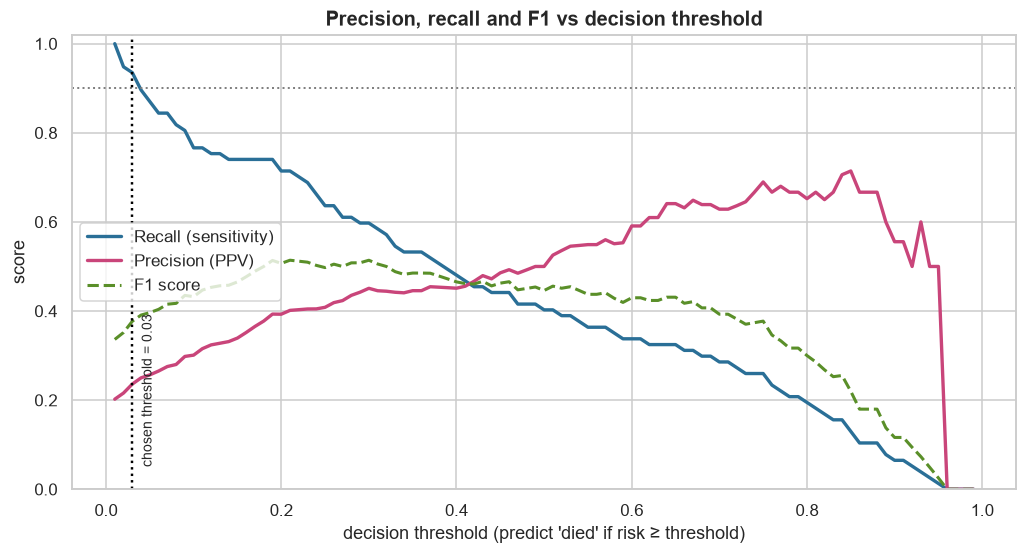

At threshold 0.03:
  sensitivity = 94%   (caught 72 of 77 deaths)
  alarms raised = 305   (of which 233 were false alarms)
  alarms per caught death ≈ 4.2  (the 'number needed to alert')


In [7]:
thresholds = np.linspace(0.01, 0.99, 99)
prec, rec, f1 = [], [], []
for t in thresholds:
    pred_t = (proba >= t).astype(int)
    tp_t = int(((pred_t == 1) & (y_test == 1)).sum())
    fp_t = int(((pred_t == 1) & (y_test == 0)).sum())
    fn_t = int(((pred_t == 0) & (y_test == 1)).sum())
    p = tp_t / (tp_t + fp_t) if (tp_t + fp_t) else 0.0
    r = tp_t / (tp_t + fn_t) if (tp_t + fn_t) else 0.0
    prec.append(p); rec.append(r)
    f1.append(2 * p * r / (p + r) if (p + r) else 0.0)
prec, rec, f1 = map(np.array, (prec, rec, f1))

TARGET_RECALL = 0.90
ok = rec >= TARGET_RECALL
# Among thresholds that hit the target sensitivity, take the one with the best precision.
t_star = thresholds[ok][np.argmax(prec[ok])]

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(thresholds, rec,  label="Recall (sensitivity)", color="#2a6f97", lw=2.2)
ax.plot(thresholds, prec, label="Precision (PPV)",      color="#c9457a", lw=2.2)
ax.plot(thresholds, f1,   label="F1 score",             color="#5a8f29", lw=2.0, ls="--")
ax.axhline(TARGET_RECALL, color="grey", ls=":", lw=1.3)
ax.axvline(t_star, color="black", ls=":", lw=1.6)
ax.text(t_star + 0.01, 0.05, f"chosen threshold = {t_star:.2f}", rotation=90, va="bottom", fontsize=9)
ax.set_title("Precision, recall and F1 vs decision threshold", fontsize=13, weight="bold")
ax.set_xlabel("decision threshold (predict 'died' if risk ≥ threshold)")
ax.set_ylabel("score"); ax.set_ylim(0, 1.02); ax.legend(loc="center left")
plt.tight_layout(); plt.show()

# What does operating at t_star cost us?
pred_star = (proba >= t_star).astype(int)
tp_s = int(((pred_star == 1) & (y_test == 1)).sum())
fp_s = int(((pred_star == 1) & (y_test == 0)).sum())
alarms = tp_s + fp_s
print(f"At threshold {t_star:.2f}:")
print(f"  sensitivity = {tp_s/(y_test==1).sum():.0%}   (caught {tp_s} of {(y_test==1).sum()} deaths)")
print(f"  alarms raised = {alarms}   (of which {fp_s} were false alarms)")
print(f"  alarms per caught death ≈ {alarms/tp_s:.1f}  (the 'number needed to alert')")

> 🧠 **Clinical takeaway.** Threshold choice is a **values decision, not a statistical one**. Lowering
> the threshold catches more deaths (↑ sensitivity) but floods the team with alarms (↓ precision → alarm
> fatigue). The right operating point depends on *what a missed death costs vs what a false alarm costs*
> in your setting — and that is a conversation for the clinical team, not the model.

## 🎯 Calibration — does "20% risk" mean 20%?

ROC-AUC only cares about **ranking** patients. But at the bedside you quote an actual number: *"this
patient has a 30% chance of dying."* For that number to be trustworthy, the model must be **calibrated** —
among all patients it labels "20% risk", about 20% should actually die.

A **reliability diagram** checks this: bin patients by predicted risk, and plot *observed* death rate vs
*predicted* risk. Perfect calibration sits on the diagonal. The **Brier score** summarises it (lower =
better; it is the mean squared error of the probabilities).

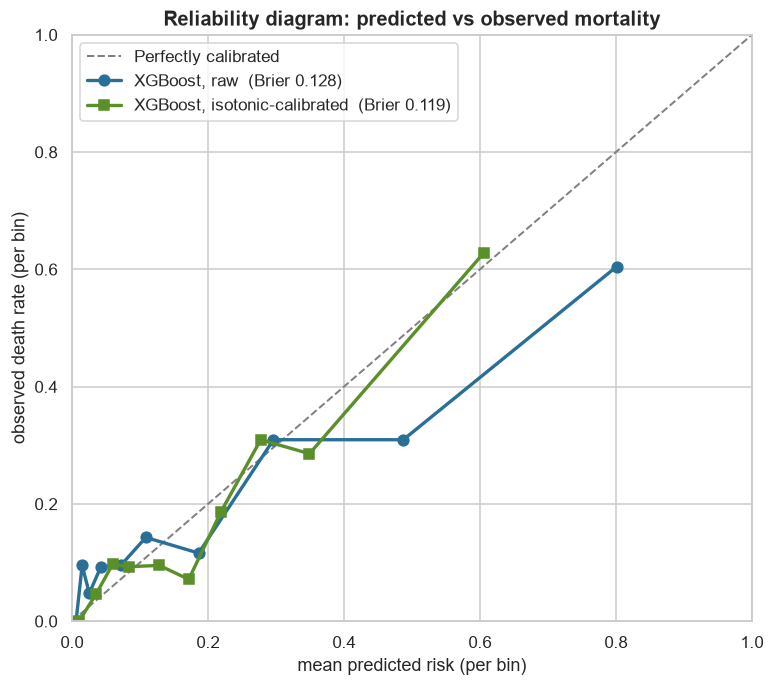

Brier score  raw = 0.128   calibrated = 0.119   (lower is better)


In [8]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# --- Recalibrate a fresh copy of the model with isotonic regression (cross-fitted on the training set)
base = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    scale_pos_weight=neg / pos, random_state=RANDOM_STATE)
calibrated = CalibratedClassifierCV(base, method="isotonic", cv=5)
calibrated.fit(X_train, y_train)
proba_cal = calibrated.predict_proba(X_test)[:, 1]

brier_raw = brier_score_loss(y_test, proba)
brier_cal = brier_score_loss(y_test, proba_cal)

frac_raw, mean_raw = calibration_curve(y_test, proba,     n_bins=10, strategy="quantile")
frac_cal, mean_cal = calibration_curve(y_test, proba_cal, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(7.2, 6.4))
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1.3, label="Perfectly calibrated")
ax.plot(mean_raw, frac_raw, "o-", color="#2a6f97", lw=2.2, ms=7,
        label=f"XGBoost, raw  (Brier {brier_raw:.3f})")
ax.plot(mean_cal, frac_cal, "s-", color="#5a8f29", lw=2.2, ms=7,
        label=f"XGBoost, isotonic-calibrated  (Brier {brier_cal:.3f})")
ax.set_title("Reliability diagram: predicted vs observed mortality", fontsize=13, weight="bold")
ax.set_xlabel("mean predicted risk (per bin)")
ax.set_ylabel("observed death rate (per bin)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

print(f"Brier score  raw = {brier_raw:.3f}   calibrated = {brier_cal:.3f}   (lower is better)")

> 🧠 **Clinical takeaway.** Tree ensembles — especially class-weighted ones — are often **miscalibrated**:
> the raw curve drifts off the diagonal, so a quoted "40% risk" might really mean something else. Isotonic
> (or Platt/sigmoid) recalibration pulls the curve back toward the diagonal and lowers the Brier score.
> **If a number will influence a treatment decision, calibrate it — and re-check calibration in every new
> hospital**, because it degrades badly across sites even when AUC looks fine.

## 👥 One more honesty check: evaluate by *patient*, not by *row*

Our patient table already has **one row per ICU stay**, so an ordinary stratified split is safe. But the
moment you evaluate on the **raw 4-hourly time-series**, the same patient has dozens of rows — and if some
land in *train* and others in *test*, the model can "recognise" the patient and your scores become
fantasy. The fix is **grouped** cross-validation, where every fold keeps a patient wholly in or wholly out.

`GroupKFold` (and `GroupShuffleSplit`) take a `groups=` array — here, `icustayid`. The tiny demo below
proves there is **zero patient overlap** between train and test folds. *(Notebook 08 shows just how much
this inflates the AUC if you get it wrong.)*

In [9]:
from sklearn.model_selection import GroupKFold

ts = load_csv("sepsis_timeseries.csv")          # the raw one-row-per-4h file
groups = ts["icustayid"].values

gkf = GroupKFold(n_splits=5)
tr_idx, te_idx = next(iter(gkf.split(ts, ts["morta_90"], groups=groups)))

train_ids = set(ts.iloc[tr_idx]["icustayid"])
test_ids  = set(ts.iloc[te_idx]["icustayid"])
overlap = train_ids & test_ids

print(f"Rows in fold-1 train: {len(tr_idx):,}   test: {len(te_idx):,}")
print(f"Unique patients  train: {len(train_ids):,}   test: {len(test_ids):,}")
print(f"Patients appearing in BOTH train and test: {len(overlap)}   ← must be 0")

✓ loaded data/sepsis_timeseries.csv
Rows in fold-1 train: 30,163   test: 7,541
Unique patients  train: 1,357   test: 339
Patients appearing in BOTH train and test: 0   ← must be 0


> 🧠 **Clinical takeaway.** *How* you split is part of the evaluation. A row-level split on time-series
> data leaks patients across the wall and reports an AUC that will **not** survive deployment. Always group
> by the patient key.

## ✏️ Your turn

Below are three exercises. Try each before opening the solution.

### ✏️ Exercise 1 — A threshold for a *ruling-out* test

Sometimes you want a **screening** rule that almost never misses a death: target **95% sensitivity**.
Find the highest threshold that still reaches 95% recall on the test set, and report the resulting
precision and the number of false alarms.

In [10]:
# TODO: reuse the `thresholds`, `proba`, and `y_test` from above.
# 1. For each threshold compute recall and precision.
# 2. Keep thresholds with recall >= 0.95.
# 3. Among those pick the highest threshold (fewest alarms) and print recall, precision, #false alarms.


<details><summary>💡 Show solution</summary>

```python
target = 0.95
best_t, best = None, None
for t in thresholds:
    pred_t = (proba >= t).astype(int)
    tp_t = int(((pred_t == 1) & (y_test == 1)).sum())
    fp_t = int(((pred_t == 1) & (y_test == 0)).sum())
    fn_t = int(((pred_t == 0) & (y_test == 1)).sum())
    r = tp_t / (tp_t + fn_t) if (tp_t + fn_t) else 0
    if r >= target:                       # thresholds are ascending -> last hit = highest t
        best_t = t
        best = (r, tp_t / (tp_t + fp_t) if (tp_t + fp_t) else 0, fp_t)
print(f"threshold {best_t:.2f}: recall={best[0]:.0%}, precision={best[1]:.0%}, false alarms={best[2]}")
```

Higher sensitivity forces a **lower** threshold, so you accept **more false alarms** (lower precision).
That is the classic screening trade-off — good for *ruling out*, noisy for *ruling in*.
</details>

### ✏️ Exercise 2 — Read a second model's PR curve

Train a plain **Logistic Regression** (inside a pipeline with median imputation + scaling, as in
Notebook 05) and plot its **Precision–Recall curve on the same axes** as the XGBoost model. Which has the
higher Average Precision?

In [11]:
# TODO:
# 1. Build a Pipeline: SimpleImputer(median) -> StandardScaler -> LogisticRegression(max_iter=2000,
#    class_weight="balanced").  Fit on X_train, y_train.
# 2. Get its test probabilities.
# 3. Plot both PR curves on one Axes with PrecisionRecallDisplay.from_predictions.


<details><summary>💡 Show solution</summary>

```python
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
    ("clf",    LogisticRegression(max_iter=2000, class_weight="balanced",
                                  random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)
proba_lr = logreg.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
PrecisionRecallDisplay.from_predictions(y_test, proba,    ax=ax, name="XGBoost",             color="#2a6f97")
PrecisionRecallDisplay.from_predictions(y_test, proba_lr, ax=ax, name="Logistic Regression", color="#c9457a")
ax.axhline(y_test.mean(), ls="--", color="grey", label="No-skill (prevalence)")
ax.set_title("PR curves: XGBoost vs Logistic Regression"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()
```

On this dataset the two are often close; XGBoost usually edges ahead on AP. The lesson is the **method**:
compare models on the curve that matches your imbalance, not on accuracy.
</details>

### ✏️ Exercise 3 — Is the logistic model better *calibrated*?

Compute the **Brier score** for the logistic-regression probabilities from Exercise 2 and compare it with
the raw XGBoost Brier score. Which model's probabilities would you trust to quote to a family?

In [12]:
# TODO: use brier_score_loss(y_test, <probabilities>) for XGBoost (raw) and Logistic Regression.


<details><summary>💡 Show solution</summary>

```python
from sklearn.metrics import brier_score_loss
print("Brier  XGBoost (raw) :", round(brier_score_loss(y_test, proba), 3))
print("Brier  LogReg        :", round(brier_score_loss(y_test, proba_lr), 3))
```

Linear models with balanced class weights are also often mis-calibrated (the weighting distorts the
base rate). Whichever wins, the honest move before quoting a probability is to **recalibrate and re-check
the reliability diagram** — a good Brier score plus a near-diagonal curve is what earns a number the right
to influence care.
</details>

## ✅ Recap

- **Accuracy lies under imbalance.** "Predict everyone survives" scores ≈82% while catching zero deaths.
  Report **sensitivity/recall** and use **balanced** metrics.
- The **confusion matrix** decomposes performance into TP/FP/FN/TN — a **false negative is a missed death**.
- **ROC/AUC** measures ranking; **Precision–Recall/AP** is the more honest summary under imbalance
  (its baseline is the prevalence, not 0.5).
- The **threshold is a clinical choice.** Sweep it, target a sensitivity, and count the **alarm burden**
  ("number needed to alert").
- **Calibration** decides whether a quoted risk is real. Check the **reliability diagram** and **Brier
  score**; recalibrate (isotonic/sigmoid) when needed — and re-check at every new site.
- Evaluate **by patient, not by row**: use `GroupKFold` on the time-series so no patient straddles the split.

## ➡️ Next

**Notebook 07 — Opening the black box with SHAP.** A good score is not enough for clinicians: we need to
know *why* the model flags a patient. We'll use permutation importance and SHAP to explain the model
globally and for a single, specific patient.